# Importação do .csv tratado

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

df = pd.read_csv('../../db/clean/obras-nao-publicitarias.csv')
df_censo = pd.read_csv('../../db/censo_2022_populacao.csv')

In [2]:
df.head()

,titulo_original,cpb,tipo_obra,classificacao_obra,duracao_total_minutos,ano_producao_inicial,segmento_destinacao_inicial,requerente,uf_requerente,municipio_requerente,cat_duracao
0,"""SOLO""",B0901120600000,FICÇÃO,BRASILEIRA INDEPENDENTE CONSTITUINTE DE ESPAÇO...,72.0,2009,INDEFINIDO,SP FILMES DE SÃO PAULO LTDA,SP,SÃO PAULO,LONGA METRAGEM
1,"""TANGO""",B0901074000000,NÃO CLASSIFICADA,NÃO INFORMADO,35.7,2009,INDEFINIDO,INTERNACIONAL - PRODUÇÕES DE CINEMA E VÍDEO LTDA,RJ,RIO DE JANEIRO,MÉDIA METRAGEM
2,"1,2,3! ÊXTASE!",B0900987500000,NÃO CLASSIFICADA,NÃO INFORMADO,5.0,2009,INDEFINIDO,CORTEX DIGITAL LTDA,RJ,RIO DE JANEIRO,CURTA METRAGEM
3,1983.. O ANO AZUL,B0901024500000,DOCUMENTÁRIO,BRASILEIRA CONSTITUINTE DE ESPAÇO QUALIFICADO,89.7,2009,INDEFINIDO,INVÍDEO PRODUÇÕES CINEMATOGRÁFICAS LTDA.,RS,PORTO ALEGRE,LONGA METRAGEM
4,1° FESTIVAL DE TEATRO DE RUA DE PORTO ALEGRE,B0901108400000,NÃO CLASSIFICADA,NÃO INFORMADO,41.1,2009,INDEFINIDO,FREDERICO AUGUSTO RUAS DOS SANTOS,RS,PORTO ALEGRE,MÉDIA METRAGEM


In [3]:
df_censo.head()

,estado,sigla,populacao
0,Acre,AC,830018
1,Alagoas,AL,3127683
2,Amapá,AP,733759
3,Amazonas,AM,3941613
4,Bahia,BA,14141626


In [4]:
censo_pop = df_censo.set_index('sigla')['populacao']
df['populacao_estado'] = df['uf_requerente'].map(censo_pop)
df['populacao_estado'] = df['populacao_estado'].astype(int)
df.head()

,titulo_original,cpb,tipo_obra,classificacao_obra,duracao_total_minutos,ano_producao_inicial,segmento_destinacao_inicial,requerente,uf_requerente,municipio_requerente,cat_duracao,populacao_estado
0,"""SOLO""",B0901120600000,FICÇÃO,BRASILEIRA INDEPENDENTE CONSTITUINTE DE ESPAÇO...,72.0,2009,INDEFINIDO,SP FILMES DE SÃO PAULO LTDA,SP,SÃO PAULO,LONGA METRAGEM,44411238
1,"""TANGO""",B0901074000000,NÃO CLASSIFICADA,NÃO INFORMADO,35.7,2009,INDEFINIDO,INTERNACIONAL - PRODUÇÕES DE CINEMA E VÍDEO LTDA,RJ,RIO DE JANEIRO,MÉDIA METRAGEM,16055174
2,"1,2,3! ÊXTASE!",B0900987500000,NÃO CLASSIFICADA,NÃO INFORMADO,5.0,2009,INDEFINIDO,CORTEX DIGITAL LTDA,RJ,RIO DE JANEIRO,CURTA METRAGEM,16055174
3,1983.. O ANO AZUL,B0901024500000,DOCUMENTÁRIO,BRASILEIRA CONSTITUINTE DE ESPAÇO QUALIFICADO,89.7,2009,INDEFINIDO,INVÍDEO PRODUÇÕES CINEMATOGRÁFICAS LTDA.,RS,PORTO ALEGRE,LONGA METRAGEM,10882965
4,1° FESTIVAL DE TEATRO DE RUA DE PORTO ALEGRE,B0901108400000,NÃO CLASSIFICADA,NÃO INFORMADO,41.1,2009,INDEFINIDO,FREDERICO AUGUSTO RUAS DOS SANTOS,RS,PORTO ALEGRE,MÉDIA METRAGEM,10882965


# Análise Univariada

## Média de duração das produções

In [5]:
media_duracao = df['duracao_total_minutos'].mean()
print(f'A média de duração é de {media_duracao:.1f} minutos.')

A média de duração é de 28.6 minutos.


Podemos ver que a duração média das produções audiovisuais brasileiras não ultrapassa 30 minutos. Isso pode indicar que há mais produções de curta e média metragem do que produções de longa metragem. Poderemos confirmar essa hipótese posteriormente na etapa de análise bivariada.

## Duração máxima das produções

In [6]:
duracao_maxima = float(df['duracao_total_minutos'].max())
print(f'O filme com maior duração possui {duracao_maxima:.1f} minutos')

O filme com maior duração possui 185.4 minutos


In [7]:
df[df['duracao_total_minutos'] == duracao_maxima]

,titulo_original,cpb,tipo_obra,classificacao_obra,duracao_total_minutos,ano_producao_inicial,segmento_destinacao_inicial,requerente,uf_requerente,municipio_requerente,cat_duracao,populacao_estado
32771,PAULO CAMILHER FLORENÇANO – UMA VIDA DEDICADA ...,B2500043700000,DOCUMENTÁRIO,BRASILEIRA INDEPENDENTE CONSTITUINTE DE ESPAÇO...,185.4,2025,TV PAGA,2BB2 PRODUÇÕES ARTÍSTICAS LTDA. - ME,RJ,RIO DE JANEIRO,LONGA METRAGEM,16055174


Podemos ver que o filme com maior duração registrado entre os anos de 2009 e 2024 possui 185,4 minutos de duração. Sendo mais específico, trata-se do documentário "Paulo Camilher Florençano - Uma Vida Dedicada à Memória de um Povo".

## Ano com mais produções audiovisuais

In [8]:
moda = df['ano_producao_inicial'].mode()[0]
print(f'A moda da coluna Ano é {moda}')

A moda da coluna Ano é 2023


Podemos ver que, entre os anos de 2009 e 2025, o ano de 2023 deteve o recorde de produções audiovisuais brasileiras. Adiante, durante a fase de análise bivariada, poderemos entender se esse valor está acompanhado de uma tendência natural de expansão do mercado ou se a razão do seu valor elevado está relacionado a um evento mais específico.

## Estado com mais produções audiovisuais

In [9]:
moda = df['uf_requerente'].mode()[0]
print(f'O estado com mais produções é {moda}')

O estado com mais produções é SP


Como esperado, o estado de São Paulo detém o maior número de produções audiovisuais no Brasil. Adiante, nas seções de análise bivariada e multivariada, veremos o quão discrepante é esse valor em relação a outros estados e regiões do Brasil.

## Categoria de duração de filme mais recorrente

In [10]:
moda = df['cat_duracao'].mode()[0]
print(f'A categoria de duração mais recorrente é {moda.lower()}')

A categoria de duração mais recorrente é curta metragem


Como esperado, a maioria das obras catalogadas são do tipo "curta metragem", ou seja, filmes cujas durações não excedem o tempo de 15 minutos. É esperado que esta categoria seja mais recorrente, haja vista os custos de produção menores, que possibilitam a sua realização mesmo em cenários com orçamento reduzido. Veremos adiante a relação entre a recorrência dessa categoria e das demais (média metragem e longa metragem).

## Segmento de destinação inicial mais recorrente

In [11]:
moda = df['segmento_destinacao_inicial'].mode()[0]
print(f'O segmento de destinação inicial mais recorrente é {moda.lower()}')

O segmento de destinação inicial mais recorrente é tv paga


# Análise Bivariada
Agora que já temos algumas noções iniciais sobre nosso conjunto de dados, podemos começar a fazer análises um pouco mais elaboradas, relacionando duas colunas de dados e extraindo informações interessantes a partir da observação da interação entre ambas. Esse tipo de análise é chamada "bivariada". A seguir, estão listadas algumas dessas análises feitas a partir da base de dados de Obras Não Publicitárias

## Análise de filmes produzidos

### Filmes produzidos por região
A análise bivariada de filmes produzidos por região nos ajuda a entender como a produção cinematográfica está distribuida entre as regiões brasileiras, se esta distribuição está balanceada e, em caso negativo, embasa discussões sobre possíveis soluções para esta assimetria. A seguir, vemos um gráfico que exibe os 10 estados brasileiros com maior produção de obras cinematográficas.

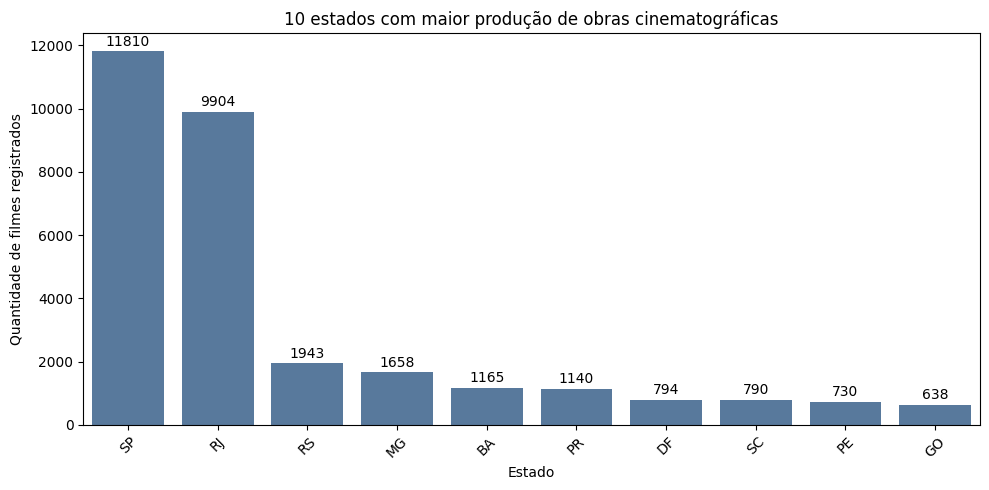

In [12]:
col = "uf_requerente"
top = df[col].value_counts().head(10).index

plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x=col, order=top, color="#4C78A8")
ax.set_xlabel('Estado')
ax.set_ylabel("Quantidade de filmes registrados")
ax.set_title(f"10 estados com maior produção de obras cinematográficas")
ax.bar_label(ax.containers[0], padding=2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O gráfico nos mostra que, dos 10 estados elencados: 3 são da região Sudeste; 3 são da região Sul; 2 são da região Nordeste; 2 são da região Centro-Oeste e nenhum é da região Norte. Isto indica que há uma clara assimetria entre as regiões brasileiras, de forma que o eixo centro-sul concentra grande parte da produção audiovisual brasileira.

### Relação entre população e produção cinematográfica

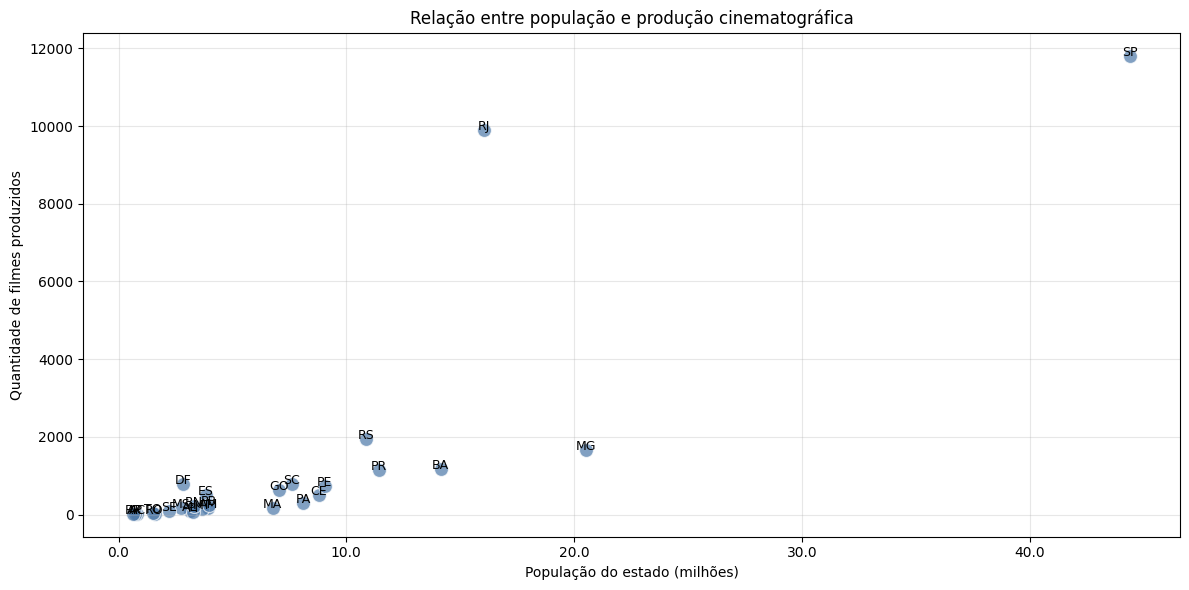

In [13]:
from matplotlib.ticker import FuncFormatter

producao_estado = df.groupby('uf_requerente').agg({
    'populacao_estado': 'first',
    'titulo_original': 'count'
}).reset_index()

plt.figure(figsize=(12,6))
ax = sns.scatterplot(data=producao_estado, x='populacao_estado', y='titulo_original',
                     s=100, alpha=0.7, color='#4C78A8')

for idx, row in producao_estado.iterrows():
    ax.text(row['populacao_estado'], row['titulo_original'], row['uf_requerente'],
            fontsize=9, ha='center')

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))

ax.set(xlabel='População do estado (milhões)', ylabel='Quantidade de filmes produzidos',
       title='Relação entre população e produção cinematográfica')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Estados com maior produção cinematográfica relativa
Entende-se como produção relativa de um estado a razão entre a população desse estado e a quantidade de produções realizadas em seu território. Essa análise nos ajuda a entender melhor a assimetria da produção cinematográfica nacional, que ainda é bastante concentrada no eixo sul-sudeste do Brasil.

### Filmes produzidos por tipo
A análise de filmes produzidos por tipo nos ajuda a compreender o estado de diversidade das produções cinematográficas brasileiras. O gráfico abaixo exibe a recorrência da produção audiovisual por tipo.

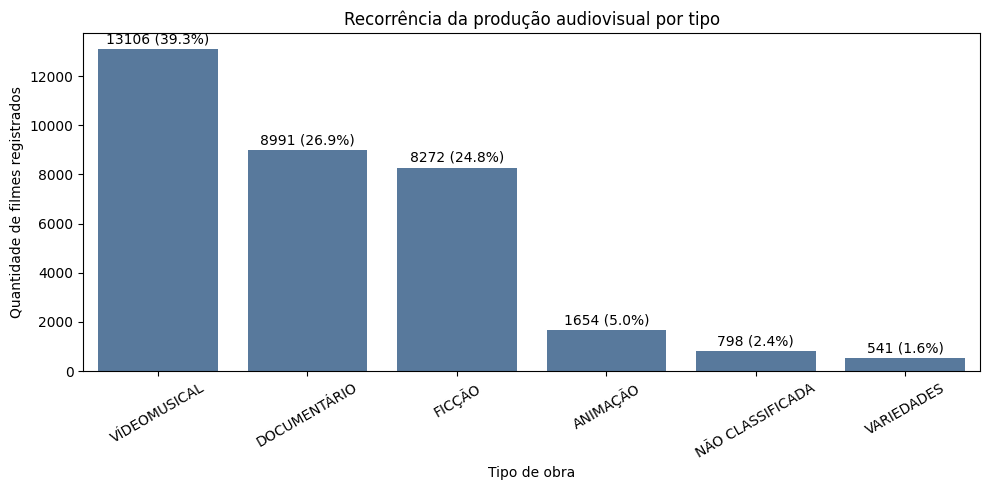

In [14]:
col = "tipo_obra"
top = df[col].value_counts().head(10).index

plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x=col, order=top, color="#4C78A8")

# Percentual ao lado do valor absoluto
n_total = df[col].notna().sum()
counts = [p.get_height() for p in ax.patches]
labels = [f"{int(c)} ({c/n_total:.1%})" for c in counts]
ax.bar_label(ax.containers[0], labels=labels, padding=2)

ax.set_xlabel('Tipo de obra')
ax.set_ylabel("Quantidade de filmes registrados")
ax.set_title(f"Recorrência da produção audiovisual por tipo")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

O gráfico acima deixa claro que obras do tipo "Vídeomusical" são as mais recorrentes, com quase 40% do total, seguido por "Documentário" e "Ficção", que seguem um certo equilíbrio entre si, com aproximadamente 27% e 25% do total, respectivamente. Obras de animação e variedades são menos recorrentes.

### Análise da produção audiovisual de filmes independentes e filmes não independentes
Ao analisar a produção de obras audiovisuais, um ponto crucial a ser considerado é a natureza das relações mercantis que as cercam. A base de dados na qual este trabalho está fundamentado foca em dois principais grupos: obras brasileiras independentes e obras brasileiras não independentes. A primeira agrega as produções cujos fundos de financiamento não estão ligados a grandes grupos do ramo audiovisual, como estúdios e emissoras de TV. Do contrário, a segunda reúne as obras as quais dependeram de financiamento advindo destas fontes para poder acontecer. O gráfico a seguir exibe esses grupos quantitativamente.

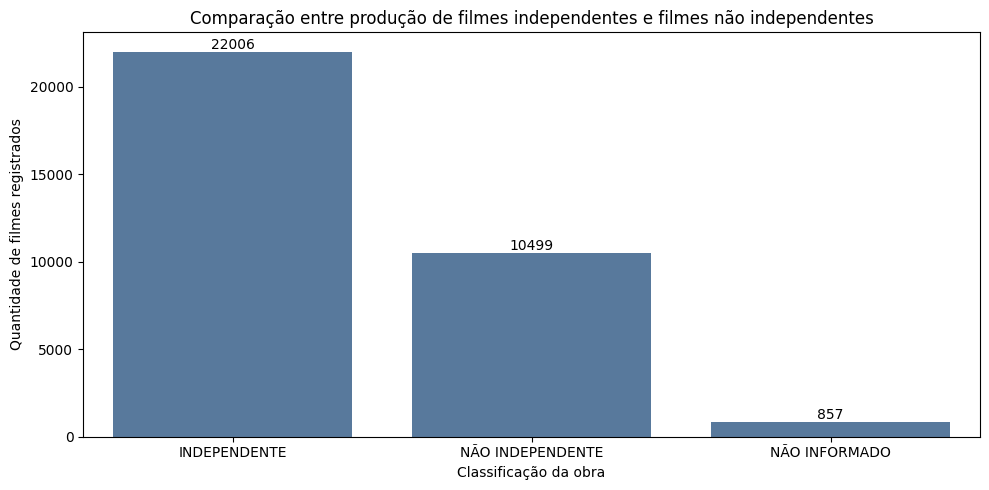

In [15]:
col = "classificacao_obra"
df[col] = df[col].replace('BRASILEIRA INDEPENDENTE CONSTITUINTE DE ESPAÇO QUALIFICADO', 'INDEPENDENTE')
df[col] = df[col].replace('BRASILEIRA CONSTITUINTE DE ESPAÇO QUALIFICADO', 'NÃO INDEPENDENTE')
top = df[col].value_counts().head(10).index

plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x=col, order=top, color="#4C78A8")
ax.set_xlabel('Classificação da obra')
ax.set_ylabel("Quantidade de filmes registrados")
ax.set_title(f"Comparação entre produção de filmes independentes e filmes não independentes")
ax.bar_label(ax.containers[0], padding=0)
plt.xticks()
plt.tight_layout()
plt.show()

Podemos ver pelo gráfico acima que a quantidade de obras independentes excede a de obras não independentes em mais do que 100%.

### Análise de filmes produzidos por duração
A análise de filmes produzidos por duração nos ajuda a compreender além dos números as obras que são produzidas em território nacional. Abre brecha para análises multivariadas que serão feitas posteriormente. O gráfico abaixo exibe o quantitativo de obras nacionais separados por duração. 

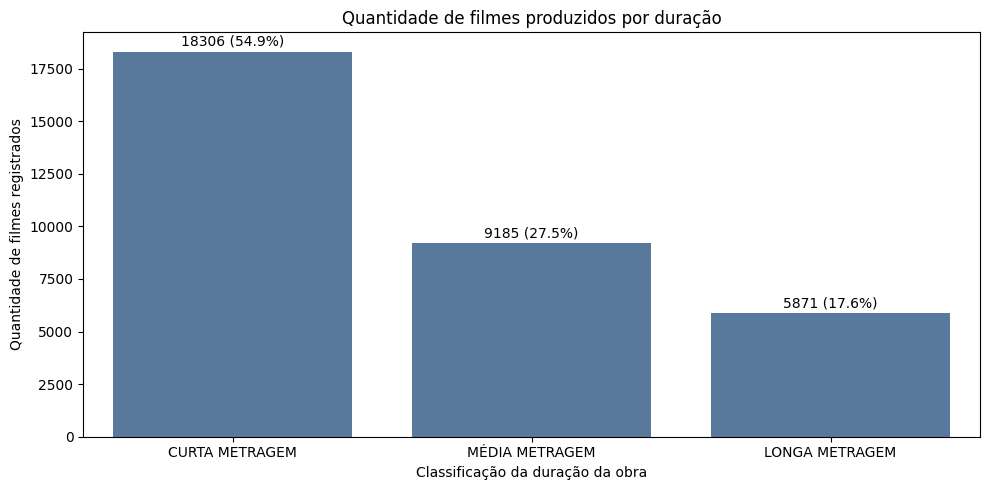

In [16]:
col = "cat_duracao"
top = df[col].value_counts().head(10).index

plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x=col, order=top, color="#4C78A8")
ax.set_xlabel('Classificação da duração da obra')
ax.set_ylabel("Quantidade de filmes registrados")
ax.set_title("Quantidade de filmes produzidos por duração")

# Percentual ao lado do valor absoluto
n_total = df[col].notna().sum()
counts = [p.get_height() for p in ax.patches]
labels = [f"{int(c)} ({c/n_total:.1%})" for c in counts]
ax.bar_label(ax.containers[0], labels=labels, padding=2)

plt.xticks()
plt.tight_layout()
plt.show()

Podemos ver através do gráfico acima que mais da metade das produções cinematográficas nacionais são curta-metragens, isto é, obras com até 15 minutos de duração. 27,5% dessas produções são de média metragem, ou seja, possuem duração maior que 15 até 70 minutos. Por fim, as obras de longa metragem, com mais de 70 minutos de duração, constituem uma minoria de 17,6%.
O gráfico também confirma a hipótese levantada anteriormente durante a etapa de análise univariada de que há mais produções de curta e média metragem do que produções de longa metragem, fato esse que influencia a média de duração das obras diminuir consideravelmente.

### Análise de filmes produzidos por ano

Analisar a quantidade de obras cinematográficas brasileiras produzidas por ano é interessante para aferir a evolução do cinema brasileiro e enxergar tendências de crescimento no mercado cinematográfico. O gráfico abaixo exibe a quantidade de filmes brasileiros produzidos por ano.

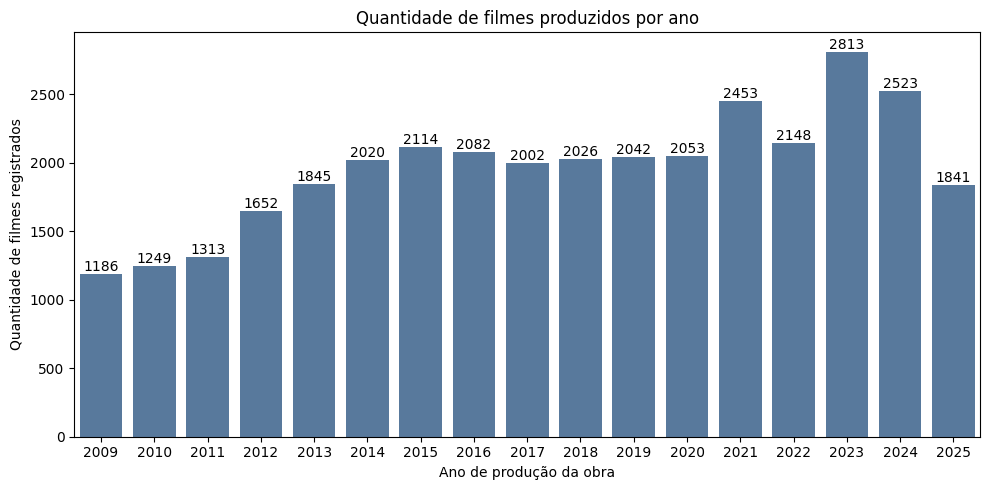

In [17]:
col = "ano_producao_inicial"
top = sorted(df[col].value_counts().index)

plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x=col, order=top, color="#4C78A8")
ax.set_xlabel('Ano de produção da obra')
ax.set_ylabel("Quantidade de filmes registrados")
ax.set_title(f"Quantidade de filmes produzidos por ano")
ax.bar_label(ax.containers[0], padding=0)
plt.xticks()
plt.tight_layout()
plt.show()

Podemos ver que 2023 e 2024 foram os anos com mais registros de obras audiovisuais desde o ano de 2009, sendo este o ano com menor registro de obras nesse intervalo de tempo. É possível visualizar um claro aumento quantitativo no número de obras, o que indica que o mercado audiovisual brasileiro está em constante aumento. A queda no ano de 2025 é, provavelmente, decorrente do fato de que o ano ainda não foi finalizado, e muitas obras ainda estão sendo registradas diariamente.
Seguindo a análise univariada feita anteriormente, conseguimos constatar que o recorde obtido no ano de 2023 não é um mero evento pontual, e sim que se trata de um sinal da expansão do mercado audiovisual brasileiro.

### Evolução da quantidade de filmes produzidos por duração

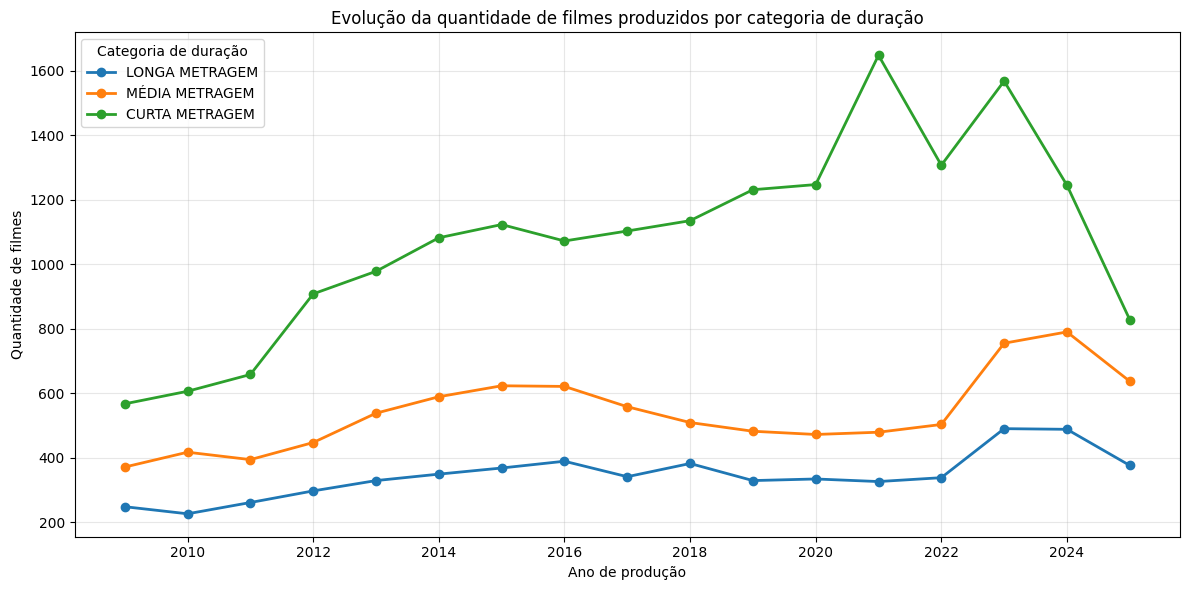

In [18]:
# Agrupar dados por ano e categoria de duração
grouped = df.groupby(['ano_producao_inicial', 'cat_duracao']).size().reset_index(name='quantidade')

# Criar o gráfico de linhas para cada categoria
plt.figure(figsize=(12,6))
for categoria in df['cat_duracao'].unique():
    dados_categoria = grouped[grouped['cat_duracao'] == categoria]
    plt.plot(dados_categoria['ano_producao_inicial'], dados_categoria['quantidade'], marker='o', label=categoria, linewidth=2)

plt.xlabel('Ano de produção')
plt.ylabel('Quantidade de filmes')
plt.title('Evolução da quantidade de filmes produzidos por categoria de duração')
plt.legend(title='Categoria de duração')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Análise Multivariada
Agora que já obtivemos diversos insights interessantes a partir de nosso conjunto de dados, utilizando as análises univariada e bivariada, é hora de elevar a compreensão do nosso conjunto de dados a um nível ainda mais acima. Para isso, faremos uso da análise multivariada: uma abordagem que considera diversos fatores simultâneos para gerar sentido e valor a uma base de dados. Levaremos em consideração os fatos e hipóteses já constatados nas etapas anteriores para melhorar ainda mais nosso entendimento sobre os dados em questão. 